# Business Impact Analysis & Simple Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import plotly.express as px
import plotly.graph_objects as go

# BUSINESS SCENARIO ANALYSIS

In [4]:
# Scenario 1: Peak Season Preparation (Black Friday)
print("SCENARIO 1: BLACK FRIDAY PREPARATION")

# Create sample data for Black Friday scenario
black_friday_data = {
    'product_id': ['P001', 'P002', 'P003', 'P004', 'P005'],
    'product_name': ['Milk', 'Bread', 'Phone Charger', 'Headphones', 'Vitamins'],
    'current_stock': [50, 30, 25, 15, 40],
    'predicted_demand': [150, 120, 80, 60, 45],
    'normal_demand': [60, 50, 30, 25, 20],
    'unit_cost': [3.5, 2.0, 15.0, 45.0, 12.0],
    'unit_price': [5.0, 3.5, 25.0, 80.0, 18.0]
}
scenario_df = pd.DataFrame(black_friday_data)
scenario_df

SCENARIO 1: BLACK FRIDAY PREPARATION


,product_id,product_name,current_stock,predicted_demand,normal_demand,unit_cost,unit_price
0,P001,Milk,50,150,60,3.5,5.0
1,P002,Bread,30,120,50,2.0,3.5
2,P003,Phone Charger,25,80,30,15.0,25.0
3,P004,Headphones,15,60,25,45.0,80.0
4,P005,Vitamins,40,45,20,12.0,18.0


In [5]:
# Calculate risk scores (simple business logic)
scenario_df['days_of_stock'] = scenario_df['current_stock'] / scenario_df['predicted_demand']
scenario_df['demand_increase'] = (scenario_df['predicted_demand'] / scenario_df['normal_demand'] - 1) * 100


In [7]:
#Simple risk categorization
def calculate_risk(row):
    if row['days_of_stock'] < 1:
        return 'HIGH_RISK'
    elif row['days_of_stock'] < 2:
        return 'STOCKOUT_RISK'
    elif row['days_of_stock'] > 10:
        return 'OVERSTOCK_RISK'
    else:
        return 'LOW_RISK'

scenario_df['risk_category'] = scenario_df.apply(calculate_risk, axis=1)


In [8]:
# Calculate potential losses
scenario_df['potential_lost_sales'] = np.maximum(0, scenario_df['predicted_demand'] - scenario_df['current_stock'])
scenario_df['lost_revenue'] = scenario_df['potential_lost_sales'] * scenario_df['unit_price']

In [9]:
print("Black Friday Risk Assessment:")
print(scenario_df[['product_name', 'current_stock', 'predicted_demand', 'risk_category', 'lost_revenue']])
print(f"\nTotal Potential Lost Revenue: ${scenario_df['lost_revenue'].sum():,.2f}")

Black Friday Risk Assessment:
    product_name  current_stock  predicted_demand risk_category  lost_revenue
0           Milk             50               150     HIGH_RISK         500.0
1          Bread             30               120     HIGH_RISK         315.0
2  Phone Charger             25                80     HIGH_RISK        1375.0
3     Headphones             15                60     HIGH_RISK        3600.0
4       Vitamins             40                45     HIGH_RISK          90.0

Total Potential Lost Revenue: $5,880.00


# ROI CALCULATION

In [10]:
# Business assumptions
monthly_revenue_per_store = 50000  # $50K per month
inventory_loss_rate_before = 0.25  # 25% losses before AI
inventory_loss_rate_after = 0.18   # 18% losses with AI (25% improvement)
implementation_cost = 2000         # One-time setup cost
monthly_maintenance = 200          # Monthly cost


In [11]:
# Calculate savings
monthly_savings_per_store = monthly_revenue_per_store * (inventory_loss_rate_before - inventory_loss_rate_after)
annual_savings_per_store = monthly_savings_per_store * 12
total_annual_cost = (implementation_cost / 12) + monthly_maintenance * 12


In [12]:
# ROI calculation
roi_monthly = (monthly_savings_per_store - monthly_maintenance) / monthly_maintenance
roi_annual = (annual_savings_per_store - total_annual_cost) / total_annual_cost


In [13]:
print(f"Monthly savings per store: ${monthly_savings_per_store:,.2f}")
print(f"Annual savings per store: ${annual_savings_per_store:,.2f}")
print(f"Total annual cost: ${total_annual_cost:,.2f}")
print(f"Annual ROI: {roi_annual:.1%}")
print(f"Payback period: {implementation_cost / monthly_savings_per_store:.1f} months")


Monthly savings per store: $3,500.00
Annual savings per store: $42,000.00
Total annual cost: $2,566.67
Annual ROI: 1536.4%
Payback period: 0.6 months


# SIMPLE PREDICTION INTERFACE

In [14]:
def predict_inventory_risk(product_name, current_stock, avg_daily_sales, days_until_reorder, is_weekend=False, is_holiday=False):
    """Simple prediction function for demo"""
    
    # Adjust sales for weekend/holiday
    predicted_daily_sales = avg_daily_sales
    if is_weekend:
        predicted_daily_sales *= 1.3
    if is_holiday:
        predicted_daily_sales *= 1.8
    
    # Calculate expected demand until reorder
    expected_demand = predicted_daily_sales * days_until_reorder
    
    # Risk calculation
    if current_stock < expected_demand * 0.5:
        risk = "HIGH_RISK"
        recommendation = f"URGENT: Order {int(expected_demand * 2)} units immediately"
    elif current_stock < expected_demand:
        risk = "STOCKOUT_RISK"
        recommendation = f"Order {int(expected_demand * 1.5)} units within 2 days"
    elif current_stock > expected_demand * 5:
        risk = "OVERSTOCK_RISK"
        recommendation = "Reduce next order by 30% or run promotion"
    else:
        risk = "LOW_RISK"
        recommendation = f"Maintain current levels, next order: {int(expected_demand)} units"
    
    # Explanation
    explanation = f"Based on {avg_daily_sales:.1f} daily sales, expecting {expected_demand:.0f} units needed in {days_until_reorder} days"
    
    return {
        'product': product_name,
        'risk_level': risk,
        'recommendation': recommendation,
        'explanation': explanation,
        'current_stock': current_stock,
        'expected_demand': expected_demand
    }


In [15]:
# Demo predictions
demo_products = [
    ("Milk", 45, 12.5, 5, True, False),
    ("Phone Charger", 8, 3.2, 7, False, True),
    ("Vitamins", 120, 4.1, 14, False, False)
]

In [18]:
print("DEMO PREDICTIONS:")
for product_data in demo_products:
    result = predict_inventory_risk(*product_data)
    print(f"\n {result['product']}")
    print(f"   Risk: {result['risk_level']}")
    print(f"   Action: {result['recommendation']}")
    print(f"   Why: {result['explanation']}")


DEMO PREDICTIONS:

 Milk
   Risk: STOCKOUT_RISK
   Action: Order 121 units within 2 days
   Why: Based on 12.5 daily sales, expecting 81 units needed in 5 days

 Phone Charger
   Risk: HIGH_RISK
   Action: URGENT: Order 80 units immediately
   Why: Based on 3.2 daily sales, expecting 40 units needed in 7 days

 Vitamins
   Risk: LOW_RISK
   Action: Maintain current levels, next order: 57 units
   Why: Based on 4.1 daily sales, expecting 57 units needed in 14 days


# BUSINESS IMPACT VISUALIZATION


=== CREATING BUSINESS IMPACT CHARTS ===


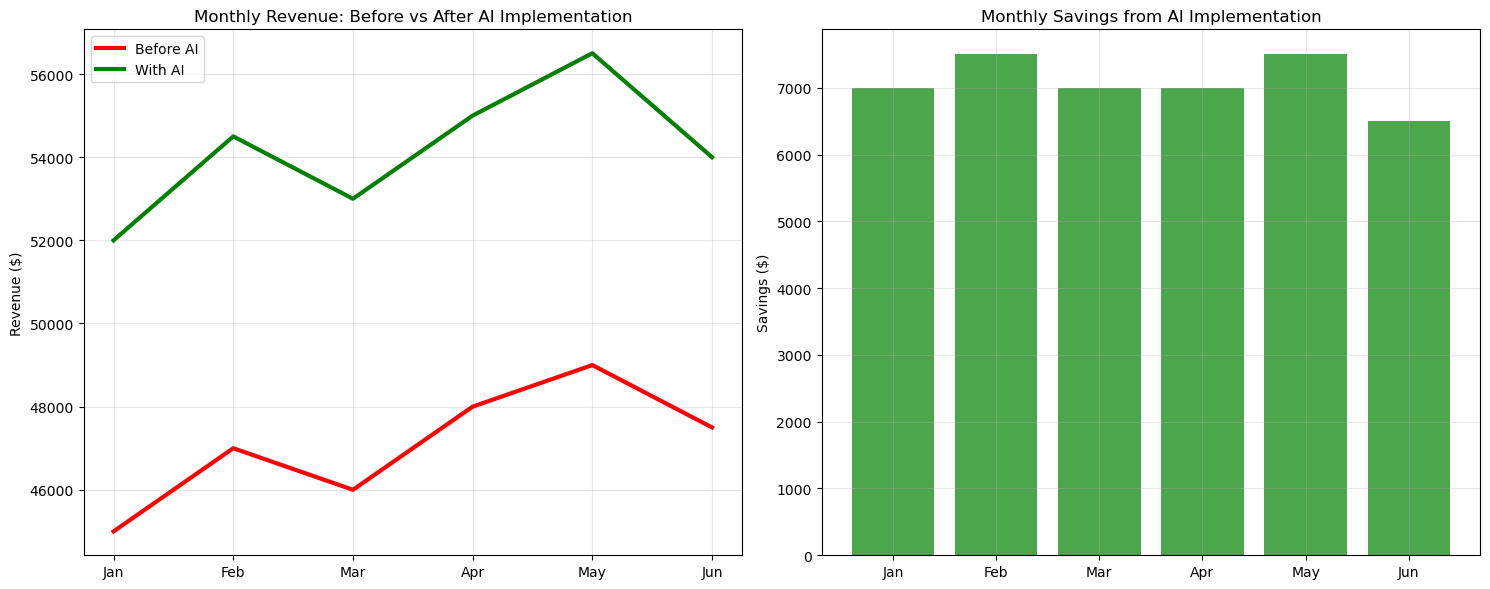

In [19]:
print("\n=== CREATING BUSINESS IMPACT CHARTS ===")

# Chart 1: Before vs After Comparison
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
revenue_before = [45000, 47000, 46000, 48000, 49000, 47500]
revenue_after = [52000, 54500, 53000, 55000, 56500, 54000]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Revenue comparison
ax1.plot(months, revenue_before, 'r-', label='Before AI', linewidth=3)
ax1.plot(months, revenue_after, 'g-', label='With AI', linewidth=3)
ax1.set_title('Monthly Revenue: Before vs After AI Implementation')
ax1.set_ylabel('Revenue ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Savings visualization
monthly_savings = [after - before for after, before in zip(revenue_after, revenue_before)]
ax2.bar(months, monthly_savings, color='green', alpha=0.7)
ax2.set_title('Monthly Savings from AI Implementation')
ax2.set_ylabel('Savings ($)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


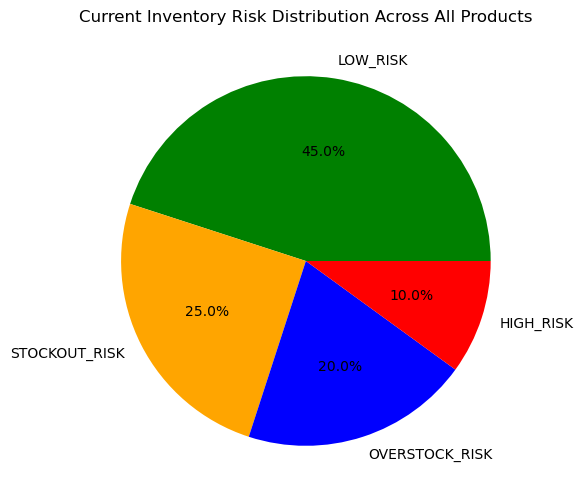

In [20]:
# Chart 2: Risk Distribution
risk_data = {'LOW_RISK': 45, 'STOCKOUT_RISK': 25, 'OVERSTOCK_RISK': 20, 'HIGH_RISK': 10}
colors = ['green', 'orange', 'blue', 'red']

plt.figure(figsize=(10, 6))
plt.pie(risk_data.values(), labels=risk_data.keys(), colors=colors, autopct='%1.1f%%')
plt.title('Current Inventory Risk Distribution Across All Products')
plt.show()